In [9]:
import pandas as pd
import statsmodels.formula.api as sm

import numpy as np
from scipy.spatial.distance import pdist, squareform

In [10]:
# preprocessing helpers
from utils import filter_words
import unicodedata
import reverse_geocoder as rg

# Helper function to normalize a string
def normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = unicodedata.normalize('NFKD', text)  # remove accents
    text = ''.join(c for c in text if not unicodedata.combining(c))  # remove diacritics
    return text

print(filter_words)
filter_words = [normalize(word) for word in filter_words]

def add_geodata(df):
    coords = df[['lat', 'lon']].dropna()
    coord_list = list(coords.itertuples(index=False, name=None))  # [(lat, lon), ...]
    
    # Perform batch reverse geocoding
    results = rg.search(coord_list)  # returns list of dicts
    
    # Create DataFrame from results and align index with original coords
    geo_df = pd.DataFrame(results, index=coords.index)[['name', 'admin1', "cc"]]
    geo_df.columns = ['city', 'state', "country"]
    
    # Merge results back into original DataFrame
    df[['city', 'state', "country"]] = geo_df
    
# From OECD 2024 - National currency per US dollar
# These values represent how many units of national currency equal 1 US dollar
ppp_per_usd = {
    'DE': 0.733194, # EUR per USD
    'AT': 0.754703, # EUR per USD
    'CH': 0.987997  # CHF per USD
}

# Use the PPP for Germany to convert USD back to EUR for final reporting
USD_TO_EUR_RATE = ppp_per_usd['DE'] # 0.733194 EUR per USD

def unify_currencies(df):
    """Converts prices to a common base (USD) using PPP data and then to EUR for reporting."""
    df['price_usd'] = df.apply(
        lambda row: row['simpleCutSalePrice'] / ppp_per_usd.get(row['country'], 1.0),
        axis=1
    )
    df['price'] = df['price_usd'] * USD_TO_EUR_RATE

    # Drop the intermediate 'price_usd' column
    df = df.drop(columns=['price_usd'])

def add_average_duration(df):
    df['duration'] = (df["simpleCutDurationMin"] + df["simpleCutDurationMax"]) / 2

def preprocess(df):
    add_geodata(df)
    print(df.columns)
    unify_currencies(df)
    add_average_duration(df)
    # Filter cuts that are shorter than 10 minutes (false positives)
    df = df[df['duration'] > 10]
    df = df[df["duration"] < 120]
    df = df[df["country"] != "LU"]
    return df.reset_index(drop=True)

['jungen', 'tönung', 'graukaschierung', 'blondieren', 'strähnen', 'färben', 'coloration', 'color', 'coloring', 'kinder', 'kids', 'junior', 'schüler', 'student', 'ansatzfarbe', 'farbe', 'blondierung', 'narbenretusche', 'geheimratsecken', 'balayage', 'hairtalk', 'extensions', 'make-up', 'dauerwelle', 'glossing', 'olaplex', 'typ beratung', 'coaching', 'colour', 'grauhaarkaschierung', 'highlights', 'abmattierung', 'sombré', 'paintings', 'cellophanes', 'babylights', 'formwelle', 'ombre', 'mesotherapie', 'mèches', 'farbservice', 'farbkur', 'mechen', 'toner', 'keratin', 'plex', 'botox', 'farbveredelung', 'farbglanz', 'tönpflege', 'strukturbehandlung', 'strähnen', 'tönung', 'cornrows', 'braids', 'mèchen', 'ombré', 'neufärbung', 'bleichen', 'dauerhaftes strecken', 'sitzungspaket', 'kerasilk', 'hairtransformation', 'färbung', 'straightperm', 'haarglättung', 'maniküre', 'pediküre', 'volumenwelle', 'narbenkorrekturen', 'permanent', 'ansatzblon', 'naturtonveredelung', 'strähnchen', 'dreads', 'farb'

In [11]:
df_adults = pd.read_csv('../data/treatwell_without_raw-all-2025-04-29.csv')\ndf_adults = preprocess(df_adults)
# Filter cuts that include one of the filter words
df_adults = df_adults[
    df_adults['simpleCutName'].apply(lambda x: not any(word in normalize(str(x)) for word in filter_words))
]
df_adults = df_adults[df_adults["price"] < 200]
print(len(df_adults))

df_children = pd.read_csv('../data/treatwell_without_raw_kids-2025-04-30.csv')\ndf_children = preprocess(df_children)
# Filter cuts that include one of the filter words
df_children = df_children[
    df_children['simpleCutName'].apply(lambda x: not any(word in normalize(str(x)) for word in filter_words[1:]))
]
df_children = df_children[df_children["price"] < 200]
print(len(df_children))

Index(['id', 'name', 'averageRating', 'ratingCount', 'simpleCutSalePrice',
       'simpleCutFullPrice', 'simpleCutDurationMin', 'simpleCutDurationMax',
       'simpleCutName', 'postalCode', 'adress', 'lat', 'lon', 'is_male',
       'is_female', 'type', 'city', 'state', 'country'],
      dtype='object')
8274
Index(['id', 'name', 'averageRating', 'ratingCount', 'simpleCutSalePrice',
       'simpleCutFullPrice', 'simpleCutDurationMin', 'simpleCutDurationMax',
       'simpleCutName', 'postalCode', 'adress', 'lat', 'lon', 'is_girls',
       'is_boys', 'is_unisex', 'type', 'city', 'state', 'country'],
      dtype='object')
1303


In [6]:
from statsmodels.formula.api import mixedlm
from stargazer.stargazer import Stargazer
basic_model = sm.ols(formula="price ~ is_female + duration", data=df_adults).fit(cov_type='cluster', cov_kwds={'groups': df_adults['id']})

controlled_model = sm.ols(formula="price ~ ratingCount + averageRating + duration * is_female", data=df_adults).fit(cov_type='cluster', cov_kwds={'groups': df_adults['id']})

fixed_effects = sm.ols(
    formula="price ~ ratingCount + averageRating + duration * is_female + C(state)",
    data=df_adults
).fit(cov_type='cluster', cov_kwds={'groups': df_adults['id']})


mixed_effects = mixedlm("price ~ ratingCount + averageRating + duration * is_female + C(state)", data=df_adults, groups=df_adults["id"]).fit()

mixed_effects_no_interaction = mixedlm("price ~ ratingCount + averageRating + duration + is_female + C(state)", data=df_adults, groups=df_adults["id"]).fit()

order = [
    'Intercept',
    'is_female[T.True]',
    'averageRating',
    'ratingCount',
    'duration',
    'duration:is_female[T.True]',
    "Group Var"
]
stargazer = Stargazer([basic_model, controlled_model, fixed_effects, mixed_effects, mixed_effects_no_interaction])
stargazer.custom_columns([
    "Baseline OLS",
    "OLS w/ Controls",
    "FE",
    "ME (w/ Interaction)",
    "ME (No Interaction)"
])
stargazer.covariate_order(order)
stargazer.rename_covariates({
    'is_female[T.True]': 'Female',
    'averageRating': 'AvgRating',
    'ratingCount': 'RatingCount',
    'duration': 'Duration',
    'duration:is_female[T.True]': 'Duration × Female',
    'Intercept': 'Const.',
    "Group Var": "Group Var"
})
stargazer.add_line('State Fixed Effects', ['No', 'No', 'Yes', 'Yes', 'Yes'])
stargazer.add_line('Salon Random Effects', ['No', 'No', 'No', 'Yes', 'Yes'])
latex_table = stargazer.render_latex()
print(latex_table)
from IPython.core.display import display, HTML
display(HTML(stargazer.render_html()))

/opt/homebrew/Caskroom/miniforge/base/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 47, but rank is 44
  warnings.warn('covariance of constraints does not have full '


\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lccccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{5}{c}{\textit{Dependent variable: price}} \
\cr \cline{2-6}
\\[-1.8ex] & \multicolumn{1}{c}{Baseline OLS} & \multicolumn{1}{c}{OLS w/ Controls} & \multicolumn{1}{c}{FE} & \multicolumn{1}{c}{ME (w/ Interaction)} & \multicolumn{1}{c}{ME (No Interaction)}  \\
\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) \\
\hline \\[-1.8ex]
 Const. & 3.799$^{***}$ & -1.069$^{}$ & 0.250$^{}$ & 3.612$^{}$ & 2.829$^{}$ \\
& (0.496) & (1.112) & (1.940) & (2.988) & (2.975) \\
 Female & 2.772$^{***}$ & 1.597$^{}$ & 1.896$^{*}$ & 1.886$^{***}$ & 3.519$^{***}$ \\
& (0.367) & (1.012) & (1.005) & (0.596) & (0.235) \\
 AvgRating & & 1.049$^{***}$ & 1.039$^{***}$ & 1.177$^{***}$ & 1.175$^{***}$ \\
& & (0.212) & (0.211) & (0.255) & (0.255) \\
 RatingCount & & 0.002$^{***}$ & 0.002$^{***}$ & 0.002$^{***}$ & 0.002$^{***}$ \\
& & (0.000) & (0.000) & (0.000) & (0.000) \\
 Duration & 0.817$^{***}$ & 0.7

/var/folders/3t/wflb1ys911b01r8mn5tknndh0000gn/T/ipykernel_58579/1069119596.py:48: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [7]:
from statsmodels.formula.api import mixedlm
from stargazer.stargazer import Stargazer
basic_model = sm.ols(formula="price ~ is_girls + is_unisex + simpleCutDurationMin", data=df_children).fit(cov_type='cluster', cov_kwds={'groups': df_children['id']})

controlled_model = sm.ols(formula="price ~ ratingCount + averageRating + duration + is_girls + is_unisex", data=df_children).fit(cov_type='cluster', cov_kwds={'groups': df_children['id']})

fixed_effects = sm.ols(
    formula="price ~ ratingCount + averageRating + (duration * is_girls) + (duration * is_unisex) + C(state)",
    data=df_children
).fit(cov_type='cluster', cov_kwds={'groups': df_children['id']})

mixed_effects = mixedlm("price ~ ratingCount + averageRating + (duration * is_girls) + (duration * is_unisex) + C(state)", data=df_children, groups=df_children["id"]).fit()

mixed_effects_no_interaction = mixedlm("price ~ ratingCount + averageRating + duration + is_girls + is_unisex + C(state)", data=df_children, groups=df_children["id"]).fit()


order = [
    'Intercept',
    'is_girls[T.True]',
    'is_unisex[T.True]',
    'averageRating',
    'ratingCount',
    'duration',
    'duration:is_girls[T.True]',
    'duration:is_unisex[T.True]',
    "Group Var"
]
stargazer = Stargazer([basic_model, controlled_model, fixed_effects, mixed_effects, mixed_effects_no_interaction])
stargazer.custom_columns([
    "Baseline OLS",
    "OLS w/ Controls",
    "FE",
    "ME (w/ Interaction)",
    "ME (No Interaction)"
])
stargazer.covariate_order(order)
stargazer.rename_covariates({
    'is_girls[T.True]': 'Female',
    'is_unisex[T.True]': 'Unisex',
    'averageRating': 'AvgRating',
    'ratingCount': 'RatingCount',
    'duration': 'Duration',
    'duration:is_girls[T.True]': 'Duration × Female',
    'duration:is_unisex[T.True]': 'Duration × Unisex',
    'Intercept': 'Const.',
    "Group Var": "Group Var"
})
stargazer.add_line('State Fixed Effects', ['No', 'No', 'Yes', 'Yes', 'Yes'])
stargazer.add_line('Salon Random Effects', ['No', 'No', 'No', 'Yes', 'Yes'])
latex_table = stargazer.render_latex()
print(latex_table)

/opt/homebrew/Caskroom/miniforge/base/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 44, but rank is 36
  warnings.warn('covariance of constraints does not have full '


\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lccccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{5}{c}{\textit{Dependent variable: price}} \
\cr \cline{2-6}
\\[-1.8ex] & \multicolumn{1}{c}{Baseline OLS} & \multicolumn{1}{c}{OLS w/ Controls} & \multicolumn{1}{c}{FE} & \multicolumn{1}{c}{ME (w/ Interaction)} & \multicolumn{1}{c}{ME (No Interaction)}  \\
\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) \\
\hline \\[-1.8ex]
 Const. & 8.128$^{***}$ & 4.016$^{**}$ & 3.043$^{}$ & 2.126$^{}$ & -0.387$^{}$ \\
& (1.145) & (1.843) & (2.788) & (3.822) & (3.738) \\
 Female & 2.176$^{***}$ & 1.749$^{***}$ & -1.113$^{}$ & -0.176$^{}$ & 1.663$^{***}$ \\
& (0.432) & (0.444) & (1.437) & (1.237) & (0.354) \\
 Unisex & 2.270$^{**}$ & 1.854$^{**}$ & -5.886$^{}$ & -6.081$^{***}$ & 1.766$^{**}$ \\
& (0.884) & (0.868) & (4.718) & (2.187) & (0.687) \\
 AvgRating & & 0.776$^{**}$ & 0.938$^{***}$ & 1.122$^{***}$ & 1.132$^{***}$ \\
& & (0.328) & (0.363) & (0.415) & (0.416) \\
 RatingCount & &

In [15]:
## descriptive statistics
stats_cols = ['price', 'duration', 'averageRating', 'ratingCount']

# Function to compute mean and std for a filtered DataFrame
def summarize_adult_group(df_group):
    means = df_group[stats_cols].mean()
    stds = df_group[stats_cols].std()
    summary = pd.concat([means, stds], axis=0)
    summary.index = [f'{col}_mean' for col in stats_cols] + [f'{col}_std' for col in stats_cols]
    return summary

# Compute summary stats for Women and Men
women_summary = summarize_adult_group(df_adults[df_adults['is_female']])
men_summary = summarize_adult_group(df_adults[~df_adults['is_female']])  # or adult_df[adult_df['is_female'] == False]

# Combine into one DataFrame
adult_stats = pd.DataFrame([women_summary, men_summary],
                           index=['Women', 'Men']).round(2)

# Add difference row (Women - Men) for means only
diff = adult_stats.loc['Women'] - adult_stats.loc['Men']
diff_std_only = pd.Series({k: '' for k in adult_stats.columns})  # Empty std values
for col in adult_stats.columns:
    if col.endswith('_mean'):
        diff_std_only[col] = diff[col]
adult_stats.loc['Diff (W - M)'] = diff_std_only

counts = {
    'Women': df_adults['is_female'].sum(),
    'Men': len(df_adults) - df_adults['is_female'].sum(),
}

adult_stats['count'] = pd.Series(counts)


# Function to compute mean and std for a filtered DataFrame
def summarize_group(df_group):
    means = df_group[stats_cols].mean()
    stds = df_group[stats_cols].std()
    summary = pd.concat([means, stds], axis=0)
    summary.index = [f'{col}_mean' for col in stats_cols] + [f'{col}_std' for col in stats_cols]
    return summary

# Create summary for each category
girls_summary = summarize_group(df_children[df_children['is_girls']])
boys_summary = summarize_group(df_children[df_children['is_boys']])
unisex_summary = summarize_group(df_children[df_children['is_unisex']])

# Combine into one DataFrame
child_stats = pd.DataFrame([girls_summary, boys_summary, unisex_summary],
                           index=['Girls', 'Boys', 'Unisex']).round(2)

counts = {
    'Girls': df_children['is_girls'].sum(),
    'Boys': df_children['is_boys'].sum(),
    'Unisex': df_children['is_unisex'].sum()
}

child_stats['count'] = pd.Series(counts)

print("Adult Haircut Stats:\n", adult_stats)
print("\nChildren Haircut Stats:\n", child_stats)

Adult Haircut Stats:
               price_mean  duration_mean  averageRating_mean  ratingCount_mean  \
Women               45.6          47.75                4.59            658.65   
Men                 32.3          34.87                4.61            627.37   
Diff (W - M)        13.3          12.88               -0.02             31.28   

             price_std duration_std averageRating_std ratingCount_std   count  
Women            21.42         17.1              0.97         1053.15  3482.0  
Men              16.19        14.46              0.95         1027.82  4792.0  
Diff (W - M)                                                              NaN  

Children Haircut Stats:
         price_mean  duration_mean  averageRating_mean  ratingCount_mean  \
Girls        27.26          34.17                4.65            891.94   
Boys         22.79          29.12                4.66            832.43   
Unisex       24.96          29.46                4.75            747.48   

      

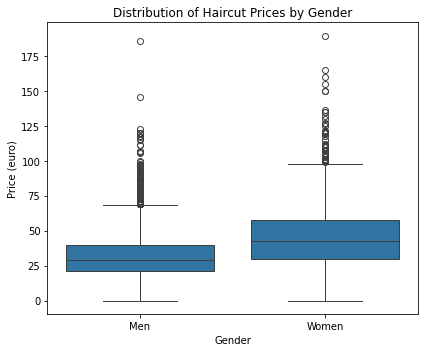

In [13]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df_adults,
    x='is_female',
    y='price'
)
plt.xticks([0, 1], ['Men', 'Women'])
plt.ylabel("Price (euro)")
plt.xlabel("Gender")
plt.title("Distribution of Haircut Prices by Gender")
plt.tight_layout()
plt.show()

In [ ]:
df_children[df_children["price"] > 100]

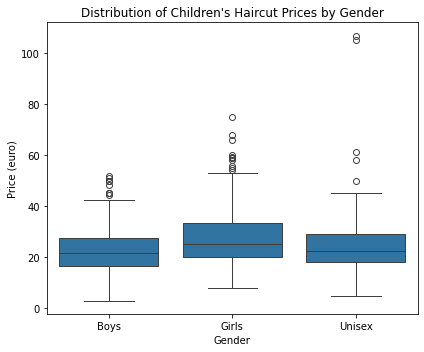

In [14]:
df_children_plot = df_children.copy()  # Avoid modifying original
df_children_plot["gender"] = df_children_plot.apply(
    lambda row: "Boys" if row["is_boys"] else ("Girls" if row["is_girls"] else "Unisex"),
    axis=1
)
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df_children_plot,
    x='gender',
    y='price',
    order=["Boys", "Girls", "Unisex"]  # consistent order
)
plt.ylabel("Price (euro)")
plt.xlabel("Gender")
plt.title("Distribution of Children's Haircut Prices by Gender")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated duration range (in minutes)
duration = np.linspace(10, 60, 100)

# Coefficients from Model (4): Mixed Effects with Interaction
intercept = 9.486
female_coef = -0.675
duration_coef = 0.461
interaction_coef = 0.089

# Predicted prices
price_boys = intercept + duration_coef * duration
price_girls = intercept + female_coef + (duration_coef + interaction_coef) * duration

# Plot
plt.figure(figsize=(8, 5))
plt.plot(duration, price_boys, label="Boys' Haircuts", color="blue")
plt.plot(duration, price_girls, label="Girls' Haircuts", color="orange")
plt.fill_between(duration, price_boys, price_girls, where=(price_girls > price_boys), 
                 color='orange', alpha=0.2, label="Price Gap")

plt.xlabel("Duration (minutes)")
plt.ylabel("Predicted Price (€)")
plt.title("Interaction Effect of Duration and Gender on Child Haircut Prices")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

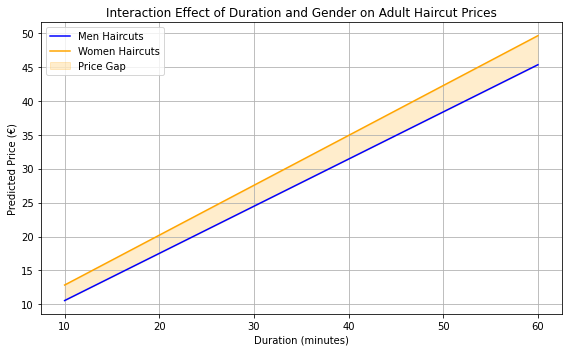

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated duration range (in minutes)
duration = np.linspace(10, 60, 100)

# Coefficients from Model (4): Mixed Effects with Interaction
intercept = 3.612
female_coef = 1.886
duration_coef = 0.695
interaction_coef = 0.040

# Predicted prices
price_men = intercept + duration_coef * duration
price_women = intercept + female_coef + (duration_coef + interaction_coef) * duration

# Plot
plt.figure(figsize=(8, 5))
plt.plot(duration, price_men, label="Men Haircuts", color="blue")
plt.plot(duration, price_women, label="Women Haircuts", color="orange")
plt.fill_between(duration, price_men, price_women, where=(price_women > price_men), 
                 color='orange', alpha=0.2, label="Price Gap")

plt.xlabel("Duration (minutes)")
plt.ylabel("Predicted Price (€)")
plt.title("Interaction Effect of Duration and Gender on Adult Haircut Prices")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# calculate price means
print(df_adults["price"].mean())
print(df_children["price"].mean())

37.89688601954357
24.865939386155908


In [ ]:
import pandas as pd
from scipy import stats # Import the stats module for t-tests

# Assuming df_adults and df_children DataFrames are already created and contain the necessary columns:
# 'price', 'duration', 'averageRating', 'ratingCount', 'is_female', 'is_girls', 'is_boys', 'is_unisex'

stats_cols = ['price', 'duration', 'averageRating', 'ratingCount']

def summarize_and_ttest_adults(df_adults):
    """
    Computes descriptive statistics and performs independent t-tests
    for the difference between Women and Men adult groups.
    """
    # Separate data for Women and Men
    df_women = df_adults[df_adults['is_female']].copy() # Use .copy() to avoid SettingWithCopyWarning
    df_men = df_adults[~df_adults['is_female']].copy() # Use .copy()

    summary_data = {}

    # Compute descriptive stats for Women and Men
    for col in stats_cols:
        summary_data[f'{col}_Women_mean'] = df_women[col].mean()
        summary_data[f'{col}_Women_std'] = df_women[col].std()
        summary_data[f'{col}_Men_mean'] = df_men[col].mean()
        summary_data[f'{col}_Men_std'] = df_men[col].std()

        # Perform independent samples t-test
        # We use equal_var=False (Welch's t-test) which does not assume equal variances
        # This is generally safer unless you have strong evidence of equal variances.
        # dropna=True is used to handle potential NaN values in the columns
        t_stat, p_value = stats.ttest_ind(
            df_women[col].dropna(),
            df_men[col].dropna(),
            equal_var=False
        )
        summary_data[f'{col}_diff_mean'] = df_women[col].mean() - df_men[col].mean()
        summary_data[f'{col}_t_stat'] = t_stat
        summary_data[f'{col}_p_value'] = p_value

    # Convert to DataFrame for better presentation
    adult_stats_df = pd.DataFrame([summary_data])

    # Reshape DataFrame for a more readable format (optional but recommended)
    # This part restructures the DataFrame to have rows for each variable and columns for stats
    output_rows = []
    for col in stats_cols:
        row_data = {
            'Variable': col,
            'Women_mean': summary_data[f'{col}_Women_mean'],
            'Women_std': summary_data[f'{col}_Women_std'],
            'Men_mean': summary_data[f'{col}_Men_mean'],
            'Men_std': summary_data[f'{col}_Men_std'],
            'Diff_mean (W - M)': summary_data[f'{col}_diff_mean'],
            'T-statistic': summary_data[f'{col}_t_stat'],
            'P-value': summary_data[f'{col}_p_value']
        }
        output_rows.append(row_data)

    adult_stats_formatted = pd.DataFrame(output_rows)

    # Add counts
    adult_stats_formatted['Women_count'] = len(df_women)
    adult_stats_formatted['Men_count'] = len(df_men)


    return adult_stats_formatted.round(3) # Round to 3 decimal places for presentation


def summarize_and_ttest_children(df_children):
    """
    Computes descriptive statistics and performs independent t-tests
    for the difference between Girls and Boys children groups.
    Also includes descriptive stats for Unisex group.
    """
    # Separate data for Girls, Boys, and Unisex
    df_girls = df_children[df_children['is_girls']].copy() # Use .copy()
    df_boys = df_children[df_children['is_boys']].copy()   # Use .copy()
    df_unisex = df_children[df_children['is_unisex']].copy() # Use .copy()


    summary_data = {}

    # Compute descriptive stats for Girls, Boys, and Unisex
    for col in stats_cols:
        summary_data[f'{col}_Girls_mean'] = df_girls[col].mean()
        summary_data[f'{col}_Girls_std'] = df_girls[col].std()
        summary_data[f'{col}_Boys_mean'] = df_boys[col].mean()
        summary_data[f'{col}_Boys_std'] = df_boys[col].std()
        summary_data[f'{col}_Unisex_mean'] = df_unisex[col].mean()
        summary_data[f'{col}_Unisex_std'] = df_unisex[col].std()

        # Perform independent samples t-test for Girls vs. Boys
        # dropna=True is used to handle potential NaN values in the columns
        t_stat, p_value = stats.ttest_ind(
            df_girls[col].dropna(),
            df_boys[col].dropna(),
            equal_var=False
        )
        summary_data[f'{col}_diff_mean (G - B)'] = df_girls[col].mean() - df_boys[col].mean()
        summary_data[f'{col}_t_stat (G vs B)'] = t_stat
        summary_data[f'{col}_p_value (G vs B)'] = p_value


    # Convert to DataFrame for better presentation
    # This part restructures the DataFrame to have rows for each variable and columns for stats
    output_rows = []
    for col in stats_cols:
        row_data = {
            'Variable': col,
            'Girls_mean': summary_data[f'{col}_Girls_mean'],
            'Girls_std': summary_data[f'{col}_Girls_std'],
            'Boys_mean': summary_data[f'{col}_Boys_mean'],
            'Boys_std': summary_data[f'{col}_Boys_std'],
            'Unisex_mean': summary_data[f'{col}_Unisex_mean'],
            'Unisex_std': summary_data[f'{col}_Unisex_std'],
            'Diff_mean (G - B)': summary_data[f'{col}_diff_mean (G - B)'],
            'T-statistic (G vs B)': summary_data[f'{col}_t_stat (G vs B)'],
            'P-value (G vs B)': summary_data[f'{col}_p_value (G vs B)']
        }
        output_rows.append(row_data)

    child_stats_formatted = pd.DataFrame(output_rows)

    # Add counts
    child_stats_formatted['Girls_count'] = len(df_girls)
    child_stats_formatted['Boys_count'] = len(df_boys)
    child_stats_formatted['Unisex_count'] = len(df_unisex)


    return child_stats_formatted.round(3) # Round to 3 decimal places for presentation



adult_stats_with_ttest = summarize_and_ttest_adults(df_adults.copy()) # Use .copy()
children_stats_with_ttest = summarize_and_ttest_children(df_children.copy()) # Use .copy()

print("Adult Haircut Stats with T-tests:\n", adult_stats_with_ttest)
print("\nChildren Haircut Stats with T-tests (Girls vs Boys):\n", children_stats_with_ttest)
